<a href="https://colab.research.google.com/github/himadri-lukhi/OIBSIP_DataAnalytics_Level1_Project1/blob/main/EDA_retail_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis on Retail Sales Data


The objective of this project is to analyze retail sales data and identify customer purchasing patterns, product performance, and sales trends.


In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Data Loading and Cleaning

In [68]:
import pandas as pd

df = pd.read_csv('retail_sales_dataset.csv')

In [69]:
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [70]:
df.shape


(1000, 9)

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [72]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [73]:
df.duplicated().sum()

np.int64(0)

Statistical summary

In [74]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [75]:
df['Date'] = pd.to_datetime(df['Date'])

In [76]:
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

Monthly Sales Trend

In [77]:
monthly_sales = df.groupby('Month')['Total Amount'].sum()
monthly_sales

,Total Amount
Month,
1,36980
2,44060
3,28990
4,33870
5,53150
6,36715
7,35465
8,36960
9,23620


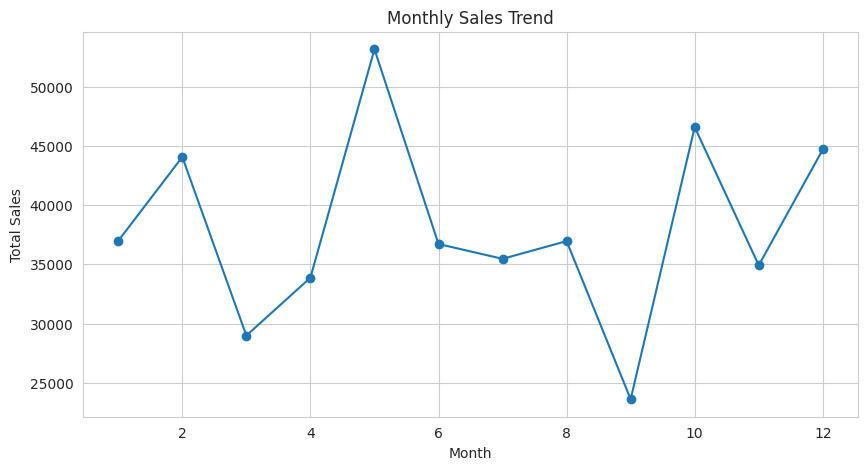

In [78]:
import matplotlib.pyplot as plt

monthly_sales.plot(
    kind='line',
    marker='o',
    figsize=(10,5)
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

Revenue by Product Category

In [79]:
total_revenue = df['Total Amount'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 456000


In [80]:
avg_transaction = df['Total Amount'].mean()
print("Average Transaction Value:", avg_transaction)

Average Transaction Value: 456.0


In [81]:
category_sales = df.groupby('Product Category')['Total Amount'].sum()
category_sales

,Total Amount
Product Category,
Beauty,143515
Clothing,155580
Electronics,156905


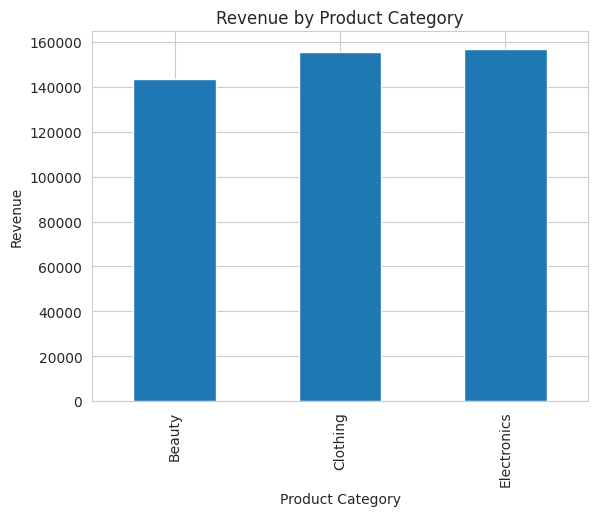

In [82]:
import matplotlib.pyplot as plt

category_sales.plot(kind='bar')
plt.title('Revenue by Product Category')
plt.ylabel('Revenue')
plt.show()

Revenue by Gender

In [83]:
df.groupby('Gender')['Total Amount'].sum()

,Total Amount
Gender,
Female,232840
Male,223160


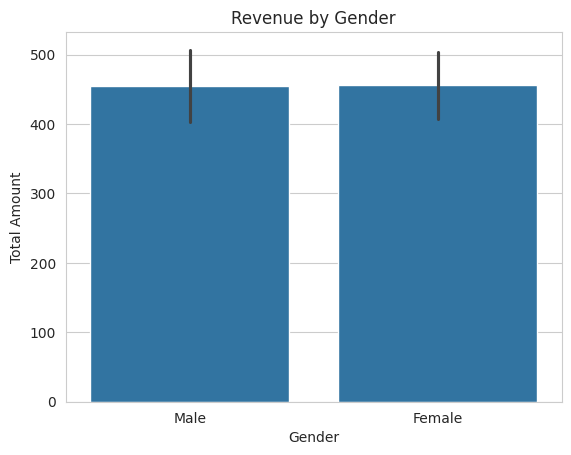

In [84]:
import seaborn as sns

sns.barplot(
    x='Gender',
    y='Total Amount',
    data=df
)
plt.title('Revenue by Gender')
plt.show()

Revenue by Age

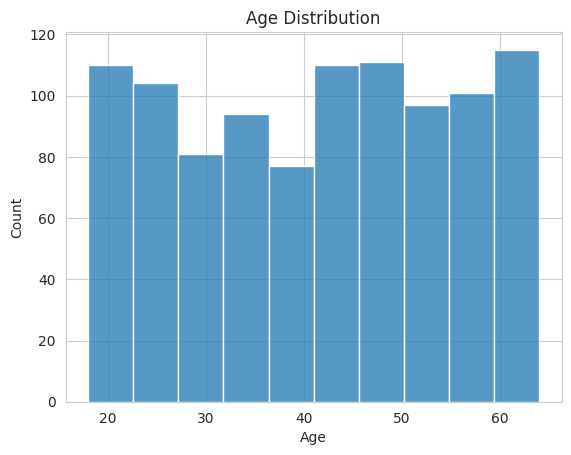

In [85]:
sns.histplot(df['Age'], bins=10)
plt.title('Age Distribution')
plt.show()

Correlation Analysis

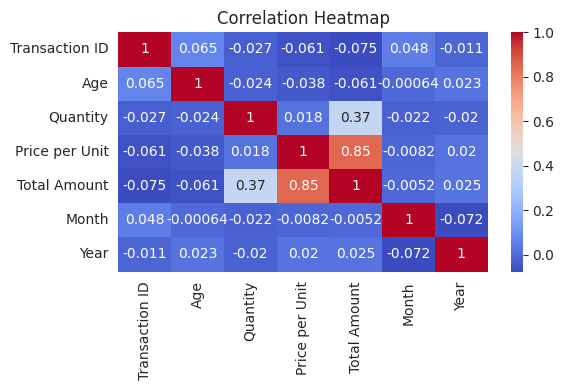

In [86]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Key Insights

1. June recorded the highest sales, while september had the lowest sales.

2. Electronics generated the highest revenue among all product categories.

3. Beauty was the lowest-performing product category.

4. Male and female customers contributed almost equally to total sales.

5. Customers around the age of 60 contributed significantly to revenue.

6. Price per Unit showed the strongest positive correlation with Total Amount.

7. Quantity purchased also had a positive impact on Total Amount.

8. Product pricing and purchase volume were the main drivers of revenue.


## Recommendations

1. Focus marketing efforts on Electronics products.

2. Improve promotions for Beauty products to increase sales.

3. Plan inventory according to peak sales months.

4. Introduce campaigns during low-sales periods such as September.

5. Target high-spending customer age groups with personalized offers.

6. Monitor pricing and product demand to maximize revenue.
